# PHYS 303 HW4: Cats vs Dogs

This notebook preprocesses the Kaggle Cats vs Dogs images, removes corrupted files, converts images to RGB, trains a binary CNN classifier with an 80/20 split, and saves the required figures and model artifacts.

In [1]:
from __future__ import annotations

import csv
import json
import os
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable

LOCAL_CACHE_DIR = Path('.cache')
LOCAL_CACHE_DIR.mkdir(exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str((LOCAL_CACHE_DIR / 'matplotlib').resolve()))
os.environ.setdefault('XDG_CACHE_HOME', str(LOCAL_CACHE_DIR.resolve()))

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image, ImageFile
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

ImageFile.LOAD_TRUNCATED_IMAGES = True

In [2]:
DATA_ROOT = Path('/Users/jjburrell/Downloads/kagglecatsanddogs_5340/PetImages')
OUTPUT_DIR = Path('phys303_hw4_outputs_notebook')
EPOCHS = 4
BATCH_SIZE = 64
IMAGE_SIZE = 64
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 0
SEED = 303
MAX_SAMPLES_PER_CLASS = None

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
device = torch.device('cpu')

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(SEED)
print({'data_root': str(DATA_ROOT), 'output_dir': str(OUTPUT_DIR), 'device': str(device)})

{'data_root': '/Users/jjburrell/Downloads/kagglecatsanddogs_5340/PetImages', 'output_dir': 'phys303_hw4_outputs_notebook', 'device': 'cpu'}


## Preprocessing and dataset definitions

The loader checks for zero-byte or unreadable files, records them, and converts every image to RGB so the network always receives 3 channels.

In [3]:
@dataclass(frozen=True)
class Sample:
    path: Path
    label: int


class PetDataset(Dataset):
    def __init__(self, samples: list[Sample], image_size: int, train: bool) -> None:
        self.samples = samples
        transform_steps: list[object] = [transforms.Resize((image_size, image_size))]
        if train:
            transform_steps.extend(
                [
                    transforms.RandomHorizontalFlip(p=0.5),
                    transforms.RandomRotation(degrees=10),
                ]
            )
        transform_steps.extend(
            [
                transforms.ToTensor(),
                transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
            ]
        )
        self.transform = transforms.Compose(transform_steps)

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, index: int) -> tuple[torch.Tensor, torch.Tensor]:
        sample = self.samples[index]
        with Image.open(sample.path) as image:
            image = image.convert('RGB')
            tensor = self.transform(image)
        label = torch.tensor(sample.label, dtype=torch.float32)
        return tensor, label


def discover_samples(
    data_root: Path, max_samples_per_class: int | None
) -> tuple[list[Sample], list[dict[str, str]], dict[str, int]]:
    samples: list[Sample] = []
    removed: list[dict[str, str]] = []
    mode_counts: dict[str, int] = {}
    label_map = {'Cat': 0, 'Dog': 1}

    for class_name, label in label_map.items():
        class_dir = data_root / class_name
        class_files = sorted(class_dir.glob('*.jpg'))
        if max_samples_per_class is not None:
            class_files = class_files[:max_samples_per_class]
        for path in class_files:
            try:
                if path.stat().st_size == 0:
                    removed.append({'path': str(path), 'label': class_name, 'reason': 'zero_bytes'})
                    continue
                with Image.open(path) as image:
                    image.verify()
                with Image.open(path) as image:
                    mode = image.mode
                mode_counts[mode] = mode_counts.get(mode, 0) + 1
                samples.append(Sample(path=path, label=label))
            except Exception as exc:
                removed.append({'path': str(path), 'label': class_name, 'reason': type(exc).__name__})
    return samples, removed, mode_counts


def split_samples(samples: list[Sample], seed: int) -> tuple[list[Sample], list[Sample]]:
    by_label: dict[int, list[Sample]] = {0: [], 1: []}
    for sample in samples:
        by_label[sample.label].append(sample)

    rng = random.Random(seed)
    train_samples: list[Sample] = []
    val_samples: list[Sample] = []

    for label_samples in by_label.values():
        rng.shuffle(label_samples)
        split_idx = int(0.8 * len(label_samples))
        train_samples.extend(label_samples[:split_idx])
        val_samples.extend(label_samples[split_idx:])

    rng.shuffle(train_samples)
    rng.shuffle(val_samples)
    return train_samples, val_samples


def make_loader(
    samples: list[Sample],
    image_size: int,
    batch_size: int,
    num_workers: int,
    shuffle: bool,
) -> DataLoader:
    dataset = PetDataset(samples=samples, image_size=image_size, train=shuffle)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=False,
    )

In [4]:
samples, removed, mode_counts = discover_samples(DATA_ROOT, MAX_SAMPLES_PER_CLASS)
train_samples, val_samples = split_samples(samples, SEED)

with (OUTPUT_DIR / 'removed_images.csv').open('w', newline='') as handle:
    writer = csv.DictWriter(handle, fieldnames=['path', 'label', 'reason'])
    writer.writeheader()
    writer.writerows(removed)

train_loader = make_loader(train_samples, IMAGE_SIZE, BATCH_SIZE, NUM_WORKERS, shuffle=True)
val_loader = make_loader(val_samples, IMAGE_SIZE, BATCH_SIZE, NUM_WORKERS, shuffle=False)

print({
    'total_valid_images': len(samples),
    'removed_images': len(removed),
    'train_size': len(train_samples),
    'validation_size': len(val_samples),
    'mode_counts_before_rgb_conversion': mode_counts,
})
removed[:5]

{'total_valid_images': 24998, 'removed_images': 2, 'train_size': 19998, 'validation_size': 5000, 'mode_counts_before_rgb_conversion': {'RGB': 24931, 'P': 57, 'L': 5, 'RGBA': 2, 'CMYK': 3}}


/Users/jjburrell/Econometrics/Econometrics/.venv/lib/python3.13/site-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


[{'path': '/Users/jjburrell/Downloads/kagglecatsanddogs_5340/PetImages/Cat/666.jpg',
  'label': 'Cat',
  'reason': 'zero_bytes'},
 {'path': '/Users/jjburrell/Downloads/kagglecatsanddogs_5340/PetImages/Dog/11702.jpg',
  'label': 'Dog',
  'reason': 'zero_bytes'}]

## Model and training functions

In [5]:
class SmallCNN(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.3),
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2),
            nn.Linear(64, 1),
        )

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.features(inputs)).squeeze(1)


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
) -> float:
    model.train()
    total_loss = 0.0
    total_examples = 0

    for features, labels in loader:
        features = features.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(features)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_examples += batch_size

    return total_loss / total_examples


def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
) -> dict[str, float | list[float]]:
    model.eval()
    total_loss = 0.0
    total_examples = 0
    all_labels: list[float] = []
    all_probs: list[float] = []

    with torch.no_grad():
        for features, labels in loader:
            features = features.to(device)
            labels = labels.to(device)
            logits = model(features)
            loss = criterion(logits, labels)
            probs = torch.sigmoid(logits)

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_examples += batch_size
            all_labels.extend(labels.cpu().numpy().tolist())
            all_probs.extend(probs.cpu().numpy().tolist())

    labels_np = np.asarray(all_labels, dtype=np.float32)
    probs_np = np.asarray(all_probs, dtype=np.float32)
    preds_np = (probs_np >= 0.5).astype(np.int32)

    return {
        'loss': total_loss / total_examples,
        'accuracy': float(accuracy_score(labels_np, preds_np)),
        'roc_auc': float(roc_auc_score(labels_np, probs_np)),
        'average_precision': float(average_precision_score(labels_np, probs_np)),
        'labels': labels_np.tolist(),
        'probs': probs_np.tolist(),
    }


def plot_curves(history: dict[str, list[float]], output_dir: Path) -> None:
    epochs = np.arange(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history['train_loss'], marker='o', label='Train loss')
    plt.plot(epochs, history['val_loss'], marker='o', label='Validation loss')
    plt.xlabel('Epoch')
    plt.ylabel('Binary cross-entropy loss')
    plt.title('Loss vs. Epoch')
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_dir / 'loss_vs_epoch.png', dpi=200)
    plt.show()
    plt.close()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history['val_accuracy'], marker='o', color='tab:green')
    plt.xlabel('Epoch')
    plt.ylabel('Validation accuracy')
    plt.title('Accuracy vs. Epoch')
    plt.tight_layout()
    plt.savefig(output_dir / 'accuracy_vs_epoch.png', dpi=200)
    plt.show()
    plt.close()


def plot_roc_and_pr(labels: Iterable[float], probs: Iterable[float], output_dir: Path) -> None:
    labels_np = np.asarray(list(labels), dtype=np.float32)
    probs_np = np.asarray(list(probs), dtype=np.float32)

    fpr, tpr, _ = roc_curve(labels_np, probs_np)
    precision, recall, _ = precision_recall_curve(labels_np, probs_np)
    auc = roc_auc_score(labels_np, probs_np)
    ap = average_precision_score(labels_np, probs_np)

    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=f'ROC AUC = {auc:.4f}')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel('False positive rate')
    plt.ylabel('True positive rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(output_dir / 'roc_curve.png', dpi=200)
    plt.show()
    plt.close()

    plt.figure(figsize=(6, 6))
    plt.plot(recall, precision, label=f'AP = {ap:.4f}', color='tab:red')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc='lower left')
    plt.tight_layout()
    plt.savefig(output_dir / 'precision_recall_curve.png', dpi=200)
    plt.show()
    plt.close()

## Train the model

This cell trains for the configured number of epochs, keeps the best checkpoint by validation accuracy, and prints the validation metrics after each epoch.

In [6]:
model = SmallCNN().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

history: dict[str, list[float]] = {
    'train_loss': [],
    'val_loss': [],
    'val_accuracy': [],
    'val_roc_auc': [],
    'val_average_precision': [],
}

best_state: dict[str, torch.Tensor] | None = None
best_accuracy = -1.0

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = evaluate(model, val_loader, criterion, device)

    history['train_loss'].append(float(train_loss))
    history['val_loss'].append(float(val_metrics['loss']))
    history['val_accuracy'].append(float(val_metrics['accuracy']))
    history['val_roc_auc'].append(float(val_metrics['roc_auc']))
    history['val_average_precision'].append(float(val_metrics['average_precision']))

    print(
        f"Epoch {epoch}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_acc={val_metrics['accuracy']:.4f} | "
        f"val_roc_auc={val_metrics['roc_auc']:.4f} | "
        f"val_ap={val_metrics['average_precision']:.4f}"
    )

    if float(val_metrics['accuracy']) > best_accuracy:
        best_accuracy = float(val_metrics['accuracy'])
        best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}

if best_state is None:
    raise RuntimeError('Training did not produce a checkpoint.')

model.load_state_dict(best_state)
final_metrics = evaluate(model, val_loader, criterion, device)
torch.save(best_state, OUTPUT_DIR / 'best_model.pt')
final_metrics

Epoch 1/4 | train_loss=0.6707 | val_loss=0.6596 | val_acc=0.6330 | val_roc_auc=0.6886 | val_ap=0.6796


/Users/jjburrell/Econometrics/Econometrics/.venv/lib/python3.13/site-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 2/4 | train_loss=0.6385 | val_loss=0.6161 | val_acc=0.6566 | val_roc_auc=0.7291 | val_ap=0.7300


/Users/jjburrell/Econometrics/Econometrics/.venv/lib/python3.13/site-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 3/4 | train_loss=0.6124 | val_loss=0.6015 | val_acc=0.6748 | val_roc_auc=0.7600 | val_ap=0.7565


/Users/jjburrell/Econometrics/Econometrics/.venv/lib/python3.13/site-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 4/4 | train_loss=0.5807 | val_loss=0.5472 | val_acc=0.7204 | val_roc_auc=0.8095 | val_ap=0.8051


{'loss': 0.5471517019748687,
 'accuracy': 0.7204,
 'roc_auc': 0.80946032,
 'average_precision': 0.8050979531680725,
 'labels': [0.0,
  1.0,
  0.0,
  1.0,
  1.0,
  1.0,
  0.0,
  0.0,
  0.0,
  1.0,
  1.0,
  1.0,
  0.0,
  1.0,
  0.0,
  1.0,
  0.0,
  1.0,
  0.0,
  1.0,
  0.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  0.0,
  1.0,
  1.0,
  0.0,
  0.0,
  1.0,
  1.0,
  0.0,
  0.0,
  1.0,
  1.0,
  0.0,
  0.0,
  0.0,
  0.0,
  1.0,
  0.0,
  0.0,
  1.0,
  0.0,
  1.0,
  0.0,
  1.0,
  0.0,
  1.0,
  0.0,
  1.0,
  1.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  1.0,
  1.0,
  0.0,
  0.0,
  1.0,
  1.0,
  0.0,
  1.0,
  0.0,
  0.0,
  1.0,
  1.0,
  1.0,
  0.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  1.0,
  0.0,
  1.0,
  0.0,
  1.0,
  1.0,
  0.0,
  1.0,
  1.0,
  0.0,
  1.0,
  0.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  1.0,
  0.0,
  0.0,
  1.0,
  1.0,
  1.0,
  1.0,
  0.0,
  1.0,
  1.0,
  0.0,
  0.0,
  1.0,
  1.0,
  0.0,
  0.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  1.0,
  1.0,

## Save figures and summary metrics

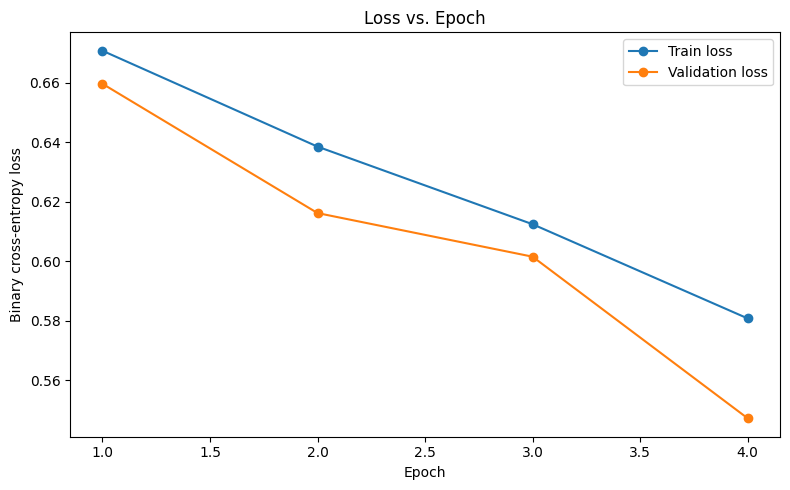

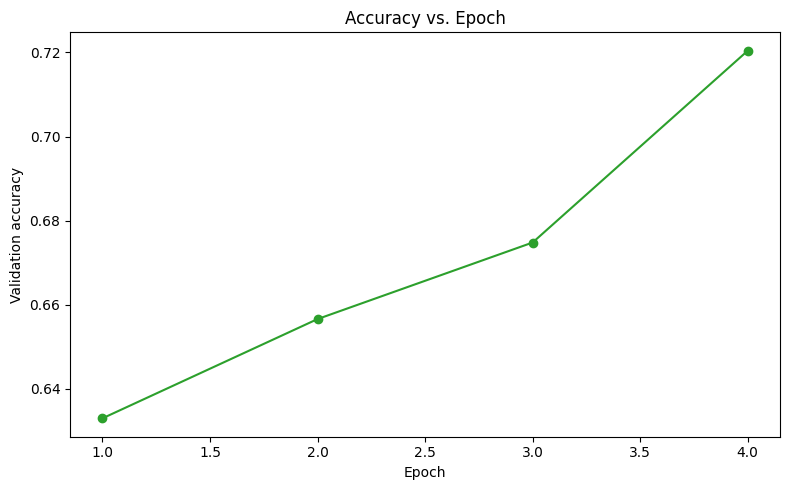

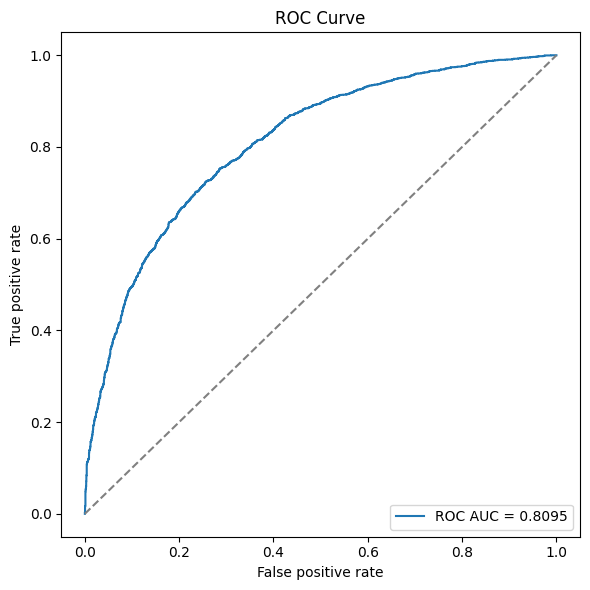

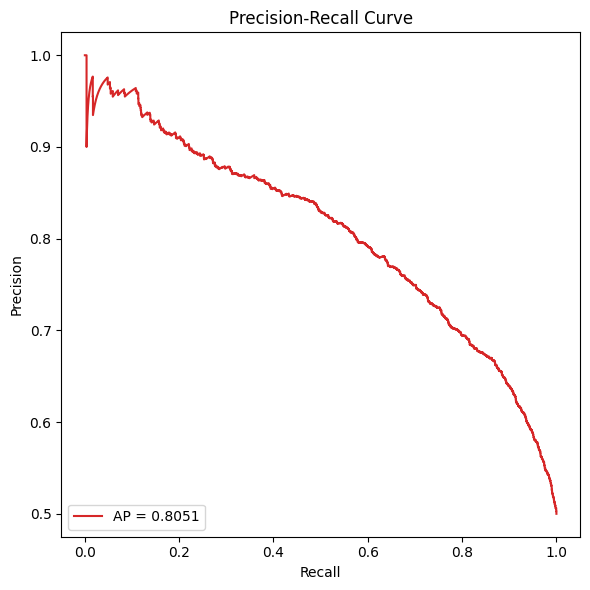

Saved outputs to: /Users/jjburrell/Econometrics/Econometrics/phys303_hw4_outputs_notebook


{'loss': 0.5471517019748687,
 'accuracy': 0.7204,
 'roc_auc': 0.80946032,
 'average_precision': 0.8050979531680725}

In [7]:
plot_curves(history, OUTPUT_DIR)
plot_roc_and_pr(final_metrics['labels'], final_metrics['probs'], OUTPUT_DIR)

metrics_payload = {
    'config': {
        'data_root': str(DATA_ROOT),
        'epochs': EPOCHS,
        'batch_size': BATCH_SIZE,
        'image_size': IMAGE_SIZE,
        'learning_rate': LEARNING_RATE,
        'weight_decay': WEIGHT_DECAY,
        'seed': SEED,
        'device': str(device),
        'max_samples_per_class': MAX_SAMPLES_PER_CLASS,
    },
    'dataset': {
        'total_valid_images': len(samples),
        'removed_images': len(removed),
        'train_size': len(train_samples),
        'validation_size': len(val_samples),
        'mode_counts_before_rgb_conversion': mode_counts,
    },
    'history': history,
    'final_validation_metrics': {
        'loss': float(final_metrics['loss']),
        'accuracy': float(final_metrics['accuracy']),
        'roc_auc': float(final_metrics['roc_auc']),
        'average_precision': float(final_metrics['average_precision']),
    },
}

with (OUTPUT_DIR / 'metrics.json').open('w') as handle:
    json.dump(metrics_payload, handle, indent=2)

print('Saved outputs to:', OUTPUT_DIR.resolve())
metrics_payload['final_validation_metrics']